In [ ]:
print("Day 1. Let's build.")

Day 1. Let's build.


In [ ]:
import pandas as pd
print("Pandas is ready")

Pandas is ready


In [ ]:
data= {
    "food": ["dal makhani", "paneer tikka", "idli", "chole bhature"],
    "calories": [320,250,90,450],
    "protein": [12,18,3,11]
}

df= pd.DataFrame(data)
print(df)

            food  calories  protein
0    dal makhani       320       12
1   paneer tikka       250       18
2           idli        90        3
3  chole bhature       450       11


In [ ]:
result= df[df["food"]=="idli"]
print(result)

   food  calories  protein
2  idli        90        3


In [ ]:
result2= df[df["food"]=="samosa"]
print(result2)

Empty DataFrame
Columns: [food, calories, protein]
Index: []


In [ ]:
## Day 2- Nutrition Dataset Exploration

In [ ]:
import pandas as pd

df= pd.read_csv("Indian_Food_Nutrition_Processed.csv")
print(df.shape)
print(df.head())

(1014, 12)
                     Dish Name  Calories (kcal)  Carbohydrates (g)  \
0         Hot tea (Garam Chai)            16.14               2.58   
1               Instant coffee            23.16               3.65   
2               Espreso coffee            51.54               6.62   
3                     Iced tea            10.34               2.70   
4  Raw mango drink (Aam panna)            35.92               9.05   

   Protein (g)  Fats (g)  Free Sugar (g)  Fibre (g)  Sodium (mg)  \
0         0.39      0.53            2.58       0.00         3.12   
1         0.64      0.75            3.62       0.00         4.92   
2         1.75      2.14            6.53       0.00        13.98   
3         0.03      0.01            2.70       0.00         0.23   
4         0.16      0.03            7.49       0.61        79.82   

   Calcium (mg)  Iron (mg)  Vitamin C (mg)  Folate (µg)  
0         14.20       0.02            0.50         1.80  
1         20.87       0.06            1.51 

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dish Name          1014 non-null   object 
 1   Calories (kcal)    1014 non-null   float64
 2   Carbohydrates (g)  1014 non-null   float64
 3   Protein (g)        1014 non-null   float64
 4   Fats (g)           1014 non-null   float64
 5   Free Sugar (g)     1014 non-null   float64
 6   Fibre (g)          1014 non-null   float64
 7   Sodium (mg)        1014 non-null   float64
 8   Calcium (mg)       1014 non-null   float64
 9   Iron (mg)          1014 non-null   float64
 10  Vitamin C (mg)     932 non-null    float64
 11  Folate (µg)        932 non-null    float64
dtypes: float64(11), object(1)
memory usage: 95.2+ KB


,0
Dish Name,0
Calories (kcal),0
Carbohydrates (g),0
Protein (g),0
Fats (g),0
Free Sugar (g),0
Fibre (g),0
Sodium (mg),0
Calcium (mg),0
Iron (mg),0


In [ ]:
df.columns= df.columns.str.strip()
df= df.drop_duplicates(subset="Dish Name")
df=df.dropna(subset=['Calories (kcal)'])
print(df.shape)

(1014, 12)


In [ ]:
def search_food(name, df):
  result= df[df['Dish Name'].str.contains(name, case=False, na= False)]
  if result.empty:
    return f"No match for '{name}'"
  return result[['Dish Name', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fats (g)']]

search_food("paneer", df)

,Dish Name,Calories (kcal),Protein (g),Carbohydrates (g),Fats (g)
40,Paneer pea sandwich (toasted) (Paneer matar ka...,249.56,12.40,24.05,11.98
94,Paneer parantha/paratha,262.97,7.98,24.33,14.62
107,Paneer pulao,581.91,1.98,8.76,59.81
134,Paneer kaathi roll,285.94,6.92,20.10,19.55
173,Pea paneer curry (Matar paneer),134.83,6.61,9.29,7.75
177,Paneer curry,176.52,7.80,8.40,12.38
182,Paneer kofta curry,670.91,2.39,3.27,72.06
188,Spinach paneer kofta curry (Palak paneer kofta...,606.03,1.43,2.94,65.41
197,Spinach paneer (Palak paneer),77.68,4.03,4.43,4.76
203,Shahi paneer,156.50,5.06,6.64,12.34


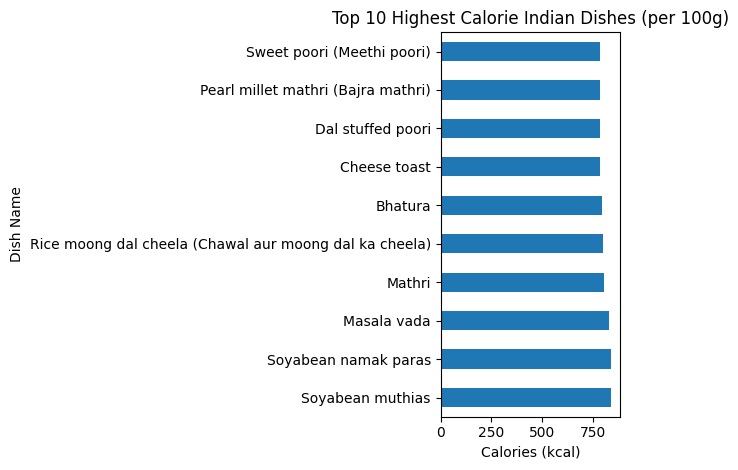

In [ ]:
import matplotlib.pyplot as plt

top10= df.nlargest(10, 'Calories (kcal)')
top10.plot(x='Dish Name', y='Calories (kcal)', kind='barh', legend= False)
plt.xlabel('Calories (kcal)')
plt.title('Top 10 Highest Calorie Indian Dishes (per 100g)')
plt.tight_layout()
plt.show()

Data was clean — no duplicate dishes, no missing values in core nutrition columns (only Vitamin C and Folate had some gaps, which weren't dropped since they're not the main focus).
Built a search function to look up any dish and see its nutrition profile.
Next question to explore: how does this data compare to what a generic nutrition tool (like MyFitnessPal) estimates for the same dish?